# **TAHAP 5** Model Evaluation

In [40]:
import os
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs(
    "/content/data/eval",
    exist_ok=True
)

# Buat Ground Truth Query

In [41]:
queries=[

{
"id":1,
"query":"pemerasan",
"expected":"pemerasan"
},

{
"id":2,
"query":"pengancaman",
"expected":"pengancaman"
},

{
"id":3,
"query":"pemerasan dan pengancaman",
"expected":"pemerasan_dan_pengancaman"
}

]


eval_rows=[]

# Evaluasi Retrieval

In [42]:
for q in queries:

    top = retrieve_case(
        q["query"],
        top_k=1
    )

    retrieved_id = top.iloc[0]["case_id"]

    pred_label = train_df[
        train_df["case_id"]==retrieved_id
    ]["jenis_perkara"].values[0]

    eval_rows.append({

        "query_id":q["id"],

        "query":q["query"],

        "actual":q["expected"],

        "predicted":pred_label
    })

retrieval_eval = pd.DataFrame(
    eval_rows
)

retrieval_eval

,query_id,query,actual,predicted
0,1,pemerasan,pemerasan,pemerasan
1,2,pengancaman,pengancaman,pengancaman
2,3,pemerasan dan pengancaman,pemerasan_dan_pengancaman,pengancaman


# Hitung Accuracy Precision Recall F1

In [43]:
acc = accuracy_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"]
)

prec = precision_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

rec = recall_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    retrieval_eval["actual"],
    retrieval_eval["predicted"],
    average="weighted",
    zero_division=0
)

metric_df = pd.DataFrame({

"accuracy":[acc],
"precision":[prec],
"recall":[rec],
"f1_score":[f1]

})

metric_df

,accuracy,precision,recall,f1_score
0,0.666667,0.5,0.666667,0.555556


# Simpan Retrieval Metrics

In [44]:
metric_df.to_csv(
"/content/data/eval/retrieval_metrics.csv",
index=False
)

print(
"saved retrieval metrics"
)

saved retrieval metrics


# Evaluasi Prediction

In [45]:
# Evaluasi Prediction

prediction_rows = []

for q in queries:

    pred = predict_outcome(
        q["query"]
    )

    top = retrieve_case(
        q["query"],
        top_k=1
    )

    retrieved_id = (
        top.iloc[0]["case_id"]
    )

    label = train_df[
        train_df["case_id"]
        ==
        retrieved_id
    ][
        "jenis_perkara"
    ].values[0]

    prediction_rows.append({

        "query_id":
        q["id"],

        "actual":
        q["expected"],

        "predicted":
        label
    })

# BUAT DATAFRAME HASIL

prediction_eval = pd.DataFrame(
    prediction_rows
)

print(
    prediction_eval
)

   query_id                     actual    predicted
0         1                  pemerasan    pemerasan
1         2                pengancaman  pengancaman
2         3  pemerasan_dan_pengancaman  pengancaman


# Hitung Metric Prediction

In [46]:
acc2 = accuracy_score(
prediction_eval["actual"],
prediction_eval["predicted"]
)

prec2 = precision_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

rec2 = recall_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

f12 = f1_score(
prediction_eval["actual"],
prediction_eval["predicted"],
average="weighted",
zero_division=0
)

prediction_metric=pd.DataFrame({

"accuracy":[acc2],
"precision":[prec2],
"recall":[rec2],
"f1_score":[f12]

})

prediction_metric

,accuracy,precision,recall,f1_score
0,0.666667,0.5,0.666667,0.555556


In [47]:
print("\n=== RETRIEVAL METRICS ===")
print(metric_df)

print("\n=== PREDICTION METRICS ===")
print(prediction_metric)


=== RETRIEVAL METRICS ===
   accuracy  precision    recall  f1_score
0  0.666667        0.5  0.666667  0.555556

=== PREDICTION METRICS ===
   accuracy  precision    recall  f1_score
0  0.666667        0.5  0.666667  0.555556


# Simpan Prediction Metrics

In [48]:
prediction_metric.to_csv(
"/content/data/eval/prediction_metrics.csv",
index=False
)

print(
"SAVED prediction metrics"
)

SAVED prediction metrics


# SIMPAN DETAIL EVALUASI

In [49]:
retrieval_eval.to_csv(
    "/content/data/eval/retrieval_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

prediction_eval.to_csv(
    "/content/data/eval/prediction_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

print("DETAIL EVALUATION SAVED")


DETAIL EVALUATION SAVED


# Error Analysis

In [50]:
print("\n=== ERROR ANALYSIS ===")

failed = prediction_eval[
    prediction_eval["actual"]
    !=
    prediction_eval["predicted"]
]

if len(failed) == 0:

    print(
        "Tidak ada prediksi gagal"
    )

else:

    print(
        "Jumlah gagal:",
        len(failed)
    )

    print(
        failed[
            [
                "query_id",
                "actual",
                "predicted"
            ]
        ]
    )


=== ERROR ANALYSIS ===
Jumlah gagal: 1
   query_id                     actual    predicted
2         3  pemerasan_dan_pengancaman  pengancaman


In [51]:
print(df["jenis_perkara"].value_counts())

jenis_perkara
pengancaman                  15
pemerasan_dan_pengancaman    10
pemerasan                     8
lain                          1
Name: count, dtype: int64


#Visualisais


In [52]:
print(
"SAVED prediction metrics"
)

SAVED prediction metrics


        Model  Accuracy  Precision    Recall        F1
0   Retrieval  0.666667        0.5  0.666667  0.555556
1  Prediction  0.666667        0.5  0.666667  0.555556


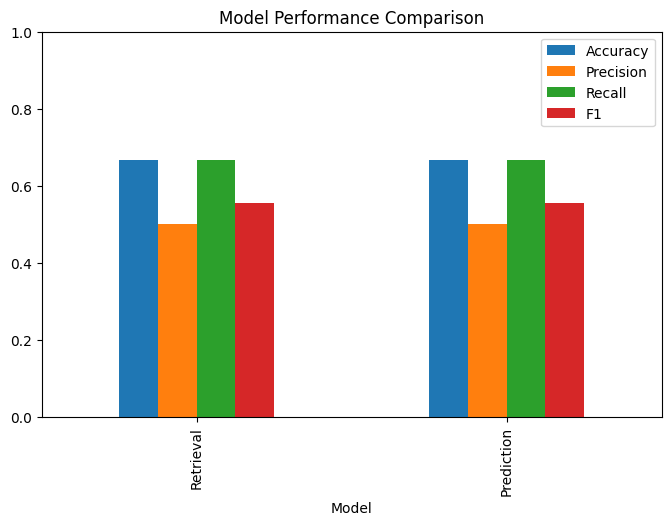

In [53]:
# VISUALISASI EVALUASI
import matplotlib.pyplot as plt
import pandas as pd

visual_df = pd.DataFrame({

"Model":[
"Retrieval",
"Prediction"
],

"Accuracy":[acc,acc2],
"Precision":[prec,prec2],
"Recall":[rec,rec2],
"F1":[f1,f12]

})

print(visual_df)

visual_df.plot(
x="Model",
kind="bar",
figsize=(8,5)
)

plt.title(
"Model Performance Comparison"
)

plt.ylim(0,1)

plt.show()

In [54]:
# SIMPAN DETAIL EVALUASI
retrieval_eval.to_csv(
"/content/data/eval/retrieval_detail.csv",
index=False,
encoding="utf-8-sig"
)

prediction_eval.to_csv(
"/content/data/eval/prediction_detail.csv",
index=False,
encoding="utf-8-sig"
)

print(
"DETAIL EVALUATION SAVED"
)

DETAIL EVALUATION SAVED
